In [1]:
import sys
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

## Training Baseline Models (Huiyu)

#### In this notebook, I train and compare seveal baseline models using the preprocessed dataset generated from `Preprocessing.py`.

In [2]:
project_root = os.path.abspath("..")
src_path = os.path.join(project_root, "src")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from src.Preprocessing import get_preprocessed_data
from src.validation import evaluate

Creating database directory...
Data folders created.
Database file found. Initializing connection...
No new CSVs to import to the database. Returning connection...
Connection initialized.


In [3]:
X_train, X_test, y_train, y_test = get_preprocessed_data()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Retrieved 68406 rows of data from the database.
Processing 68406 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Finished transforming log(lastPriceByZip).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning artifact...
Finished imputation for BedroomsTotal.
Found pre-trained imputer model for BathroomsTotalInteger. Returning artifact...
Finished imputation for BathroomsTotalInteger.
Finished impu

In [4]:
print("Feature columns:")
print(X_train.columns)

assert "ClosePrice" not in X_train.columns

print("\nFeature dtypes:")
print(X_train.dtypes)

na_counts = X_train.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
print("\nMissing values per column:")
print(na_counts)

Feature columns:
Index(['Latitude', 'Longitude', 'PostalCode', 'AttachedGarageYN',
       'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'GarageSpaces',
       'LivingArea', 'MainLevelBedrooms', 'NewConstructionYN', 'ParkingTotal',
       'PoolPrivateYN', 'Stories', 'ViewYN', 'YearBuilt', 'HighSchoolDistrict',
       'LotSizeArea', 'AssociationFee', 'CloseDate', 'DaysOnMarket',
       'sin_closed_date', 'cos_closed_date', 'log_lastPriceByZip',
       'Flooring_Bamboo', 'Flooring_Brick', 'Flooring_Carpet',
       'Flooring_Concrete', 'Flooring_Laminate', 'Flooring_SeeRemarks',
       'Flooring_Stone', 'Flooring_Tile', 'Flooring_Vinyl', 'Flooring_Wood',
       'Levels_MultiSplit', 'Levels_One', 'Levels_ThreeOrMore', 'Levels_Two'],
      dtype='object')

Feature dtypes:
Latitude                        float64
Longitude                       float64
PostalCode                      float64
AttachedGarageYN                float64
BathroomsTotalInteger           float64
BedroomsTota

In [5]:
# Drop raw datetime column; keep cyclical features instead
X_train_model = X_train.drop(columns=["CloseDate"], errors="ignore").copy()
X_test_model = X_test.drop(columns=["CloseDate"], errors="ignore").copy()

print("Modeling feature shape (train/test):", X_train_model.shape, X_test_model.shape)
print("\nDtype summary:")
print(X_train_model.dtypes.value_counts())

Modeling feature shape (train/test): (58668, 37) (8762, 37)

Dtype summary:
float64    36
bool        1
Name: count, dtype: int64


#### Define evaluation metrics

#### I evaluate the baseline models using RMSE and R-square.

In [6]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name}")
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-"*30)

#### Train baseline models (*)

In this step, I chose the following models as the baseline starting point:
- Linear Regression
- Ridge Regression
- Random Forest
- XGBoost

In [7]:
# Linear Regression baseline
lin_model = LinearRegression()
lin_model.fit(X_train_model, y_train)
lin_pred = lin_model.predict(X_test_model)
evaluate_model("Linear Regression", y_test, lin_pred)

# Ridge Regression baseline
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_model, y_train)
ridge_pred = ridge_model.predict(X_test_model)
evaluate_model("Ridge Regression", y_test, ridge_pred)

# Random Forest baseline
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_model, y_train)
rf_pred = rf_model.predict(X_test_model)
evaluate_model("Random Forest", y_test, rf_pred)

# XGBoost baseline
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)
xgb_model.fit(X_train_model, y_train)
xgb_pred = xgb_model.predict(X_test_model)
evaluate_model("XGBoost", y_test, xgb_pred)

Linear Regression
RMSE: 0.23216820929688986
R2: 0.7805107360035604
------------------------------
Ridge Regression
RMSE: 0.23216533405285902
R2: 0.7805161724178763
------------------------------
Random Forest
RMSE: 0.18725692823400236
R2: 0.857214676880683
------------------------------
XGBoost
RMSE: 0.1720635674690173
R2: 0.8794448896381007
------------------------------


#### Baseline results summary

##### As we can see from the results, tree-based models perform much better than linear models.

##### Linear / Ridge models reach around 0.55 R-square. Random Forest and XGBoost reach around 0.87 R-square. This shows that the relationship between features and ClosePrice is highly non-linear.


#### Tuning Random Forest (*)

In [8]:
rf_candidates = [
    {
        "model_name": "RF_baseline_reference",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_more_trees",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_shallower_trees",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
    },
    {
        "model_name": "RF_regularized_split",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 4,
    },
    {
        "model_name": "RF_stronger_regularization",
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_split": 10,
        "min_samples_leaf": 4,
    },
]

rf_tuning_results = []
best_rf_model = None
best_rf_result = None
best_r2 = -np.inf

for config in rf_candidates:
    rf_tuned_model = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_split=config["min_samples_split"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )

    rf_tuned_model.fit(X_train_model, y_train)
    rf_tuned_pred = rf_tuned_model.predict(X_test_model)

    rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))
    r2 = r2_score(y_test, rf_tuned_pred)

    result_row = {
        "model_name": config["model_name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_split": config["min_samples_split"],
        "min_samples_leaf": config["min_samples_leaf"],
        "RMSE": rmse,
        "R2": r2
    }

    rf_tuning_results.append(result_row)

    print(f'Model: {config["model_name"]}')
    print(f'Parameters: {config}')
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-" * 50)

    if r2 > best_r2:
        best_r2 = r2
        best_rf_model = rf_tuned_model
        best_rf_result = result_row


rf_results_df = pd.DataFrame(rf_tuning_results)
rf_results_df = rf_results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("Random Forest tuning summary:")
display(rf_results_df)


print("Best Random Forest configuration:")
print(best_rf_result)

best_rf_pred = best_rf_model.predict(X_test_model)

print("\nBest tuned Random Forest performance:")
evaluate_model("Best Tuned Random Forest", y_test, best_rf_pred)

Model: RF_baseline_reference
Parameters: {'model_name': 'RF_baseline_reference', 'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.18725692823400233
R2: 0.857214676880683
--------------------------------------------------
Model: RF_more_trees
Parameters: {'model_name': 'RF_more_trees', 'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.18682172703058814
R2: 0.8578775963815506
--------------------------------------------------
Model: RF_shallower_trees
Parameters: {'model_name': 'RF_shallower_trees', 'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1}
RMSE: 0.187671100546842
R2: 0.856582357125332
--------------------------------------------------
Model: RF_regularized_split
Parameters: {'model_name': 'RF_regularized_split', 'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4}
RMSE: 0.18599220110191325
R2: 0.859136898323901
-----------

,model_name,n_estimators,max_depth,min_samples_split,min_samples_leaf,RMSE,R2
0,RF_regularized_split,200,20.0,10,4,0.185992,0.859137
1,RF_more_trees,300,NaN,2,1,0.186822,0.857878
2,RF_baseline_reference,200,NaN,2,1,0.187257,0.857215
3,RF_shallower_trees,200,20.0,2,1,0.187671,0.856582
4,RF_stronger_regularization,300,15.0,10,4,0.187898,0.856236


Best Random Forest configuration:
{'model_name': 'RF_regularized_split', 'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4, 'RMSE': 0.18599220110191325, 'R2': 0.859136898323901}

Best tuned Random Forest performance:
Best Tuned Random Forest
RMSE: 0.1859922011019133
R2: 0.8591368983239009
------------------------------


#### Tuning XGBoost (*)

In [9]:
xgb_candidates = [
    {
        "model_name": "XGB_baseline_reference",
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_more_trees",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_lower_learning_rate",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_shallower_trees",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "model_name": "XGB_more_regularized_sampling",
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
    },
]



xgb_tuning_results = []
best_xgb_model = None
best_xgb_result = None
best_xgb_r2 = -np.inf

for config in xgb_candidates:
    xgb_tuned_model = XGBRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )

    xgb_tuned_model.fit(X_train_model, y_train)
    xgb_tuned_pred = xgb_tuned_model.predict(X_test_model)

    rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_pred))
    r2 = r2_score(y_test, xgb_tuned_pred)

    result_row = {
        "model_name": config["model_name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "learning_rate": config["learning_rate"],
        "subsample": config["subsample"],
        "colsample_bytree": config["colsample_bytree"],
        "RMSE": rmse,
        "R2": r2
    }

    xgb_tuning_results.append(result_row)

    print(f'Model: {config["model_name"]}')
    print(f'Parameters: {config}')
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-" * 50)

    if r2 > best_xgb_r2:
        best_xgb_r2 = r2
        best_xgb_model = xgb_tuned_model
        best_xgb_result = result_row



xgb_results_df = pd.DataFrame(xgb_tuning_results)
xgb_results_df = xgb_results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("XGBoost tuning summary:")
display(xgb_results_df)



print("Best XGBoost configuration:")
print(best_xgb_result)

best_xgb_pred = best_xgb_model.predict(X_test_model)

print("\nBest tuned XGBoost performance:")
evaluate_model("Best Tuned XGBoost", y_test, best_xgb_pred)

Model: XGB_baseline_reference
Parameters: {'model_name': 'XGB_baseline_reference', 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.1720635674690173
R2: 0.8794448896381007
--------------------------------------------------
Model: XGB_more_trees
Parameters: {'model_name': 'XGB_more_trees', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.16845891285448125
R2: 0.8844431310143611
--------------------------------------------------
Model: XGB_lower_learning_rate
Parameters: {'model_name': 'XGB_lower_learning_rate', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE: 0.173262861796032
R2: 0.8777584788329638
--------------------------------------------------
Model: XGB_shallower_trees
Parameters: {'model_name': 'XGB_shallower_trees', 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsam

,model_name,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,RMSE,R2
0,XGB_more_trees,300,6,0.10,0.8,0.8,0.168459,0.884443
1,XGB_baseline_reference,200,6,0.10,0.8,0.8,0.172064,0.879445
2,XGB_lower_learning_rate,300,6,0.05,0.8,0.8,0.173263,0.877758
3,XGB_shallower_trees,200,4,0.10,0.8,0.8,0.182713,0.864060
4,XGB_more_regularized_sampling,300,4,0.05,0.7,0.7,0.184999,0.860638


Best XGBoost configuration:
{'model_name': 'XGB_more_trees', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'RMSE': 0.16845891285448125, 'R2': 0.8844431310143611}

Best tuned XGBoost performance:
Best Tuned XGBoost
RMSE: 0.16845891285448125
R2: 0.8844431310143611
------------------------------


#### GridSearchCV for Random Forest

In [10]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train_model, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.889620772305698


In [11]:
best_rf = rf_grid.best_estimator_
rf_tuned_pred = best_rf.predict(X_test_model)

evaluate_model("Tuned Random Forest", y_test, rf_tuned_pred)

Tuned Random Forest
RMSE: 0.17364523416983005
R2: 0.8772183358714034
------------------------------


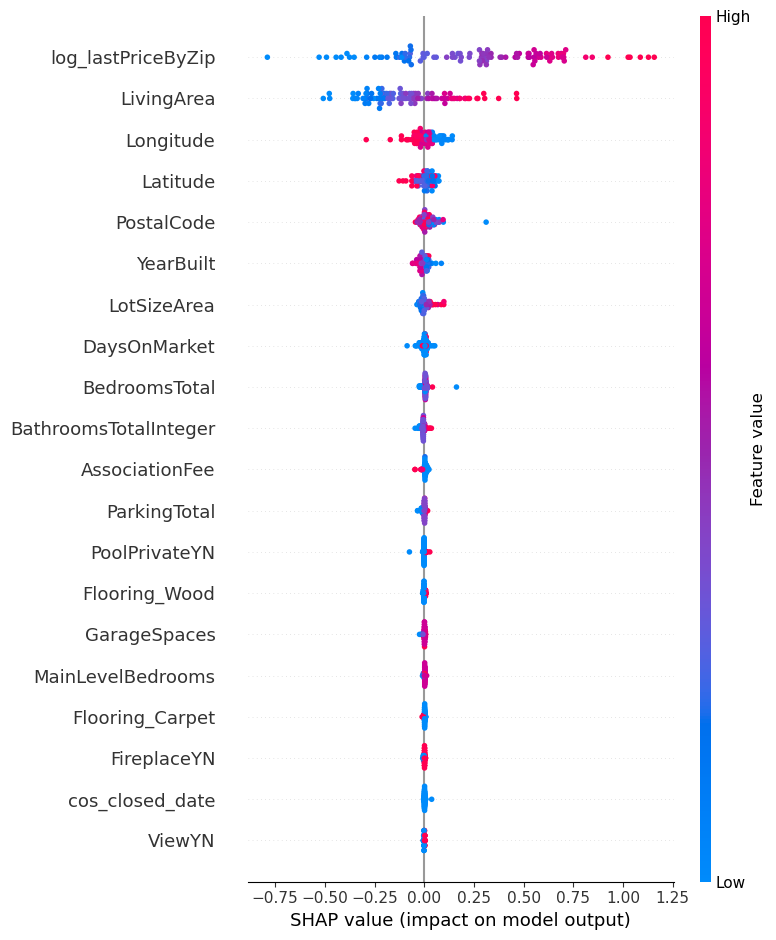

In [12]:
import shap

X_shap = X_test_model.iloc[:100]
explainer = shap.TreeExplainer(rf_model)   
shap_val = explainer.shap_values(X_shap)
shap.summary_plot(shap_val, X_shap)

#### Linear Regression with Continuous Features

In this section, I explore a simpler linear model using only continuous features.

The goal is to evaluate whether a linear relationship between features and target
can achieve competitive performance compared to tree-based models.

If performance is not satisfactory, I will consider engineering additional features.

In [14]:
continuous_cols = [
    'Latitude',
    'Longitude',
    'BathroomsTotalInteger',
    'BedroomsTotal',
    'GarageSpaces',
    'LivingArea',
    'MainLevelBedrooms',
    'ParkingTotal',
    'Stories',
    'YearBuilt',
    'LotSizeArea',
    'AssociationFee',
    'DaysOnMarket',
    'sin_closed_date'
]

X_train_cont = X_train[continuous_cols]
X_test_cont = X_test[continuous_cols]

lr = LinearRegression()
lr.fit(X_train_cont, y_train)

y_pred = lr.predict(X_test_cont)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("RMSE (log scale):", rmse)
print("R^2:", r2)

RMSE (log scale): 0.33639869044373394
R^2: 0.5391958605303631


#### Engineer new features

In [16]:
X_train_cont = X_train_cont.copy()
X_test_cont = X_test_cont.copy()

# Feature engineering
X_train_cont['HouseAge'] = 2026 - X_train_cont['YearBuilt']
X_test_cont['HouseAge'] = 2026 - X_test_cont['YearBuilt']

X_train_cont['AreaPerRoom'] = X_train_cont['LivingArea'] / (X_train_cont['BedroomsTotal'] + 1)
X_test_cont['AreaPerRoom'] = X_test_cont['LivingArea'] / (X_test_cont['BedroomsTotal'] + 1)

X_train_cont['log_LivingArea'] = np.log1p(X_train_cont['LivingArea'])
X_test_cont['log_LivingArea'] = np.log1p(X_test_cont['LivingArea'])


# Clean after feature engineering
X_train_cont = X_train_cont.replace([np.inf, -np.inf], np.nan)
X_test_cont = X_test_cont.replace([np.inf, -np.inf], np.nan)

X_train_cont = X_train_cont.fillna(X_train_cont.median())
X_test_cont = X_test_cont.fillna(X_train_cont.median())

# Refit model
lr_new = LinearRegression()
lr_new.fit(X_train_cont, y_train)

y_pred_new = lr_new.predict(X_test_cont)

rmse_new = mean_squared_error(y_test, y_pred_new, squared=False)
r2_new = r2_score(y_test, y_pred_new)

print("New RMSE:", rmse_new)
print("New R^2:", r2_new)

New RMSE: 0.33483757446360063
New R^2: 0.5434628184533512


In [17]:
print("Baseline RMSE:", rmse)
print("Baseline R^2:", r2)
print("New RMSE:", rmse_new)
print("New R^2:", r2_new)

Baseline RMSE: 0.33639869044373394
Baseline R^2: 0.5391958605303631
New RMSE: 0.33483757446360063
New R^2: 0.5434628184533512
